In [4]:
# Cell 1: Setup
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from pydantic import BaseModel, Field
from typing_extensions import Literal

load_dotenv()

llm = ChatOpenAI(model="gpt-4o-mini")
search_tool = TavilySearchResults(max_results=2)
from typing import TypedDict
from langgraph.graph import StateGraph, END, START

In [6]:
class Route(BaseModel):
    """Classifier output — the LLM must pick exactly one of these labels."""
    label: Literal["billing", "technical", "general"] = Field(
        description="Category of the customer's message."
    )

router_llm = llm.with_structured_output(Route)

class SupportState(TypedDict):
    message: str
    route: str
    answer: str

def classify(state: SupportState):
    decision = router_llm.invoke(
        f"Classify this customer message:\n{state['message']}"
    )
    return {"route": decision.label}

def billing_agent(state: SupportState):
    msg = llm.invoke(f"You are a billing specialist. Help with: {state['message']}")
    return {"answer": msg.content}

def technical_agent(state: SupportState):
    msg = llm.invoke(f"You are a senior support engineer. Debug: {state['message']}")
    return {"answer": msg.content}

def general_agent(state: SupportState):
    msg = llm.invoke(f"You are a friendly general agent. Reply to: {state['message']}")
    return {"answer": msg.content}

rt = StateGraph(SupportState)
rt.add_node("classify",  classify)
rt.add_node("billing",   billing_agent)
rt.add_node("technical", technical_agent)
rt.add_node("general",   general_agent)

rt.add_edge(START, "classify")
rt.add_conditional_edges(
    "classify",
    lambda s: s["route"],
    {"billing": "billing", "technical": "technical", "general": "general"}
)
rt.add_edge("billing",   END)
rt.add_edge("technical", END)
rt.add_edge("general",   END)
rt_graph = rt.compile()

for sample in [
    "My credit card was charged twice for the same order.",
    "The app crashes every time I try to upload a file over 5 MB.",
    "Do you guys have a holiday discount this December?",
]:
    out = rt_graph.invoke({"message": sample})
    print(f"INPUT : {sample}")
    print(f"ROUTE : {out['route']}")
    print(f"REPLY : {out['answer']}...\n")

INPUT : My credit card was charged twice for the same order.
ROUTE : billing
REPLY : I'm sorry to hear that you've been charged twice for the same order. Here are some steps you can take to resolve the issue:

1. **Verify the Charges**: Check your credit card statement to confirm that the charge appears twice. Make sure both charges are indeed for the same order.

2. **Gather Information**: Collect all relevant details related to the order, including:
   - Order number
   - Date of order
   - Amount charged
   - Confirmation emails or receipts

3. **Contact Customer Service**: Reach out to the customer service department of the company you ordered from. You can usually find contact information on their website. Explain the situation clearly and provide them with the order details you gathered.

4. **Request a Refund**: Ask them to investigate the duplicate charge and request a refund for the extra amount charged.

5. **Check with Your Credit Card Issuer**: If you don’t receive a satisf

In [8]:
from IPython.display import Image, display

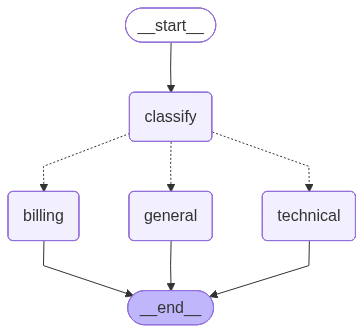

In [9]:
try:
    display(Image(rt_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(rt_graph.get_graph().draw_ascii())